In [1]:
students_data = """name,math,science,english,history,pe,attendance_pct,study_hours_per_day,passed
Alice,88,92,76,80,95,92,4.5,1
Bob,42,55,48,50,60,65,1.2,0
Charlie,75,70,80,68,88,85,3.0,1
Diana,95,98,91,89,97,98,6.0,1
Eve,38,42,50,45,55,58,0.8,0
Frank,60,65,72,58,70,78,2.5,1
Grace,55,48,44,52,62,60,1.5,0
Henry,82,79,85,77,90,88,4.0,1
Iris,70,74,68,65,78,80,3.5,1
Jack,30,35,40,28,45,50,0.5,0
Karen,65,60,70,62,75,72,2.8,1
Liam,48,52,44,55,58,62,1.8,0
Mia,91,94,88,92,96,95,5.5,1
Noah,58,62,55,60,68,70,2.0,0
Olivia,78,75,82,70,85,84,3.8,1"""

with open("students.csv", "w") as f:
    f.write(students_data)

In [2]:
# Task 1 — Data Exploration with Pandas
import pandas as pd

df = pd.read_csv("students.csv")

# Printing the first 5 rows
print("=== First 5 Rows ===")
print(df.head())

# Shape and data types
print(f"\nShape : {df.shape}")
print("\nData Types:")
print(df.dtypes)

# Summary statistics
print("\nSummary Statistics")
print(df.describe())

# Count Pass/Fail
print("\nPass/Fail Count: ")
print(df['passed'].value_counts())

# Average score per subject for passing vs failing students
subject_cols = ['math', 'science', 'english', 'history', 'pe']

print("\nAverage Scores — Passing Students ")
print(df[df['passed'] == 1][subject_cols].mean())

print("\nAverage Scores — Failing Students ")
print(df[df['passed'] == 0][subject_cols].mean())

# Student with highest overall average
df['temp_avg'] = df[subject_cols].mean(axis=1)
top_student = df.loc[df['temp_avg'].idxmax(), 'name']
top_avg = df['temp_avg'].max()
print(f"\nTop Student : {top_student} with average {top_avg:.2f}")
df.drop(columns=['temp_avg'], inplace=True)

=== First 5 Rows ===
      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape : (15, 9)

Data Types:
name                    object
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary Statistics
            math    science    engl

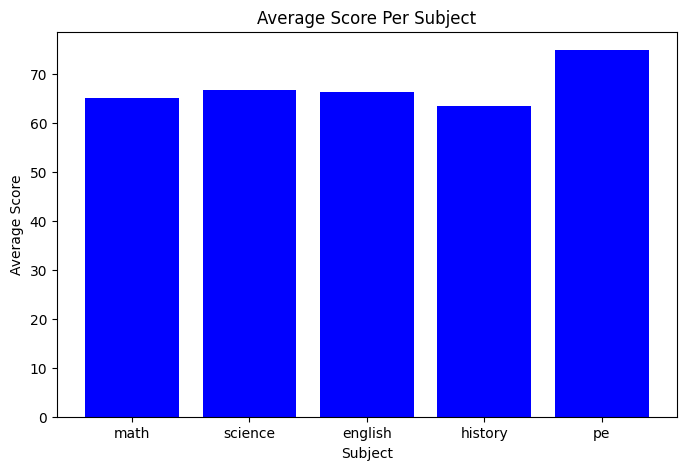

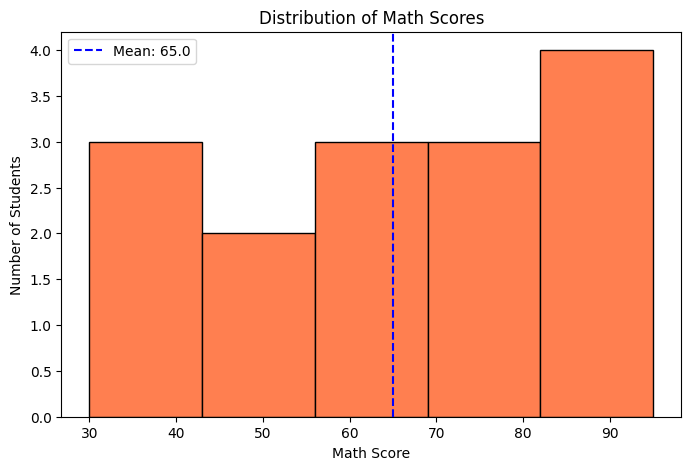

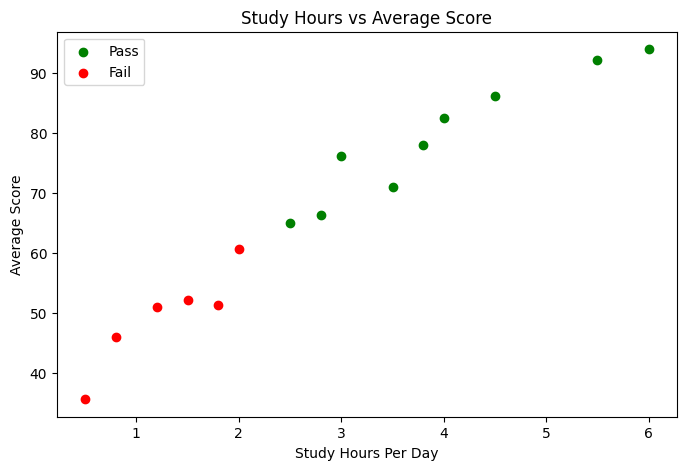

/tmp/ipykernel_22325/146445447.py:50: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])


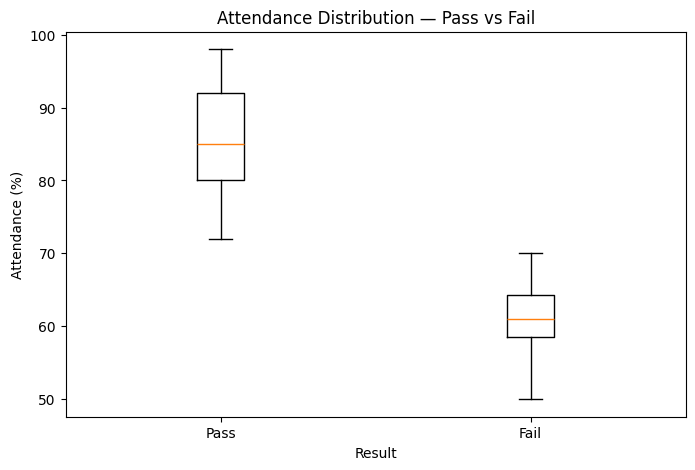

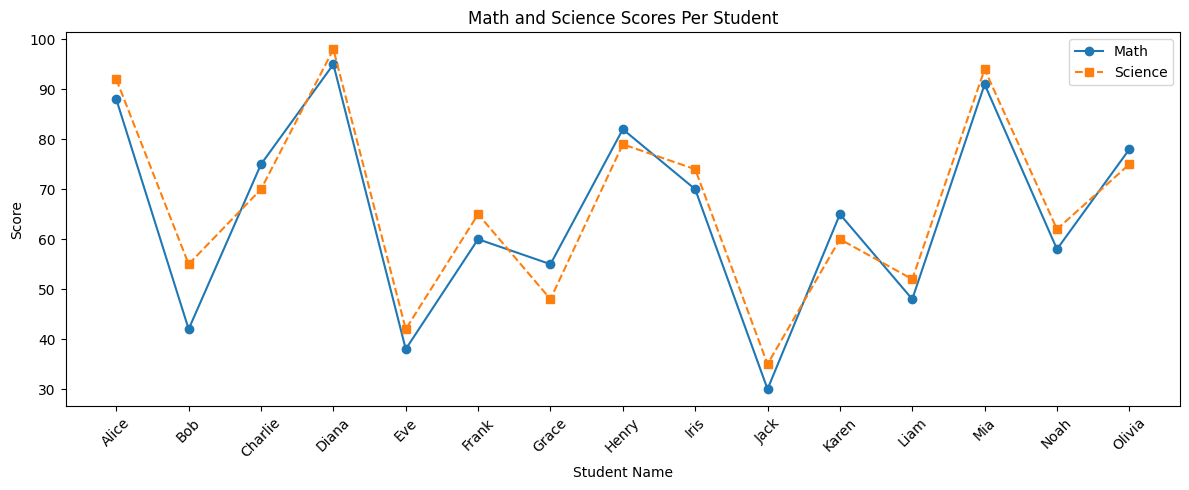

In [3]:
# Task 2 — Data Visualization with Matplotlib
import matplotlib.pyplot as plt

subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)

# 1. Bar Chart: Average score per subject
avg_per_subject = df[subject_cols].mean()

plt.figure(figsize=(8, 5))
plt.bar(subject_cols, avg_per_subject, color='blue')
plt.title("Average Score Per Subject")
plt.xlabel("Subject")
plt.ylabel("Average Score")
plt.savefig("plot1_bar.png")
plt.show()

# 2. Histogram: Distribution of math scores
mean_math = df['math'].mean()

plt.figure(figsize=(8, 5))
plt.hist(df['math'], bins=5, color='coral', edgecolor='black')
plt.axvline(mean_math, color='blue', linestyle='--', label=f'Mean: {mean_math:.1f}')
plt.title("Distribution of Math Scores")
plt.xlabel("Math Score")
plt.ylabel("Number of Students")
plt.legend()
plt.savefig("plot2_histogram.png")
plt.show()

# 3. Scatter Plot: Study hours vs avg score coloured by passed
pass_students = df[df['passed'] == 1]
fail_students = df[df['passed'] == 0]

plt.figure(figsize=(8, 5))
plt.scatter(pass_students['study_hours_per_day'], pass_students['avg_score'], color='green', label='Pass')
plt.scatter(fail_students['study_hours_per_day'], fail_students['avg_score'], color='red', label='Fail')
plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours Per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()

# 4. Box Plot: Attendance for Pass vs Fail
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure(figsize=(8, 5))
plt.boxplot([pass_attendance, fail_attendance], labels=['Pass', 'Fail'])
plt.title("Attendance Distribution — Pass vs Fail")
plt.xlabel("Result")
plt.ylabel("Attendance (%)")
plt.savefig("plot4_boxplot.png")
plt.show()

# 5. Line Plot: Math and Science scores per student
plt.figure(figsize=(12, 5))
plt.plot(df['name'], df['math'], marker='o', linestyle='-', label='Math')
plt.plot(df['name'], df['science'], marker='s', linestyle='--', label='Science')
plt.title("Math and Science Scores Per Student")
plt.xlabel("Student Name")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("plot5_line.png")
plt.show()

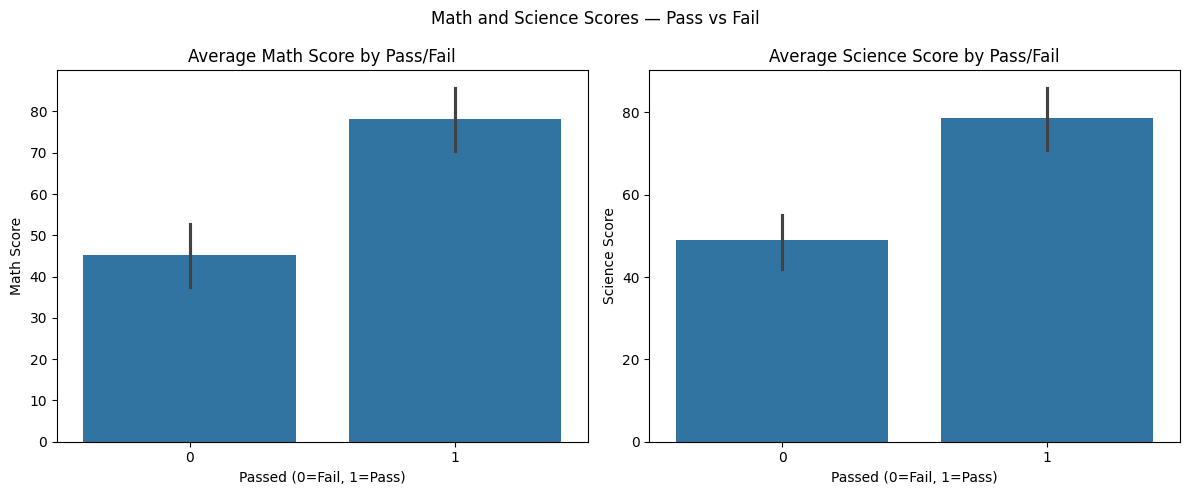

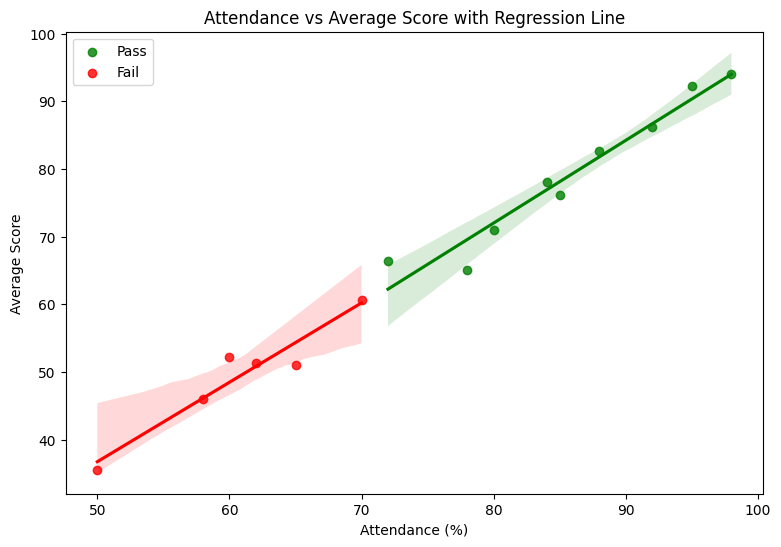

In [4]:
# Task 3 — Data Visualization with Seaborn
import seaborn as sns

# 6. Seaborn Bar Plot: Average math and science score by passed
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score by Pass/Fail")
ax1.set_xlabel("Passed (0=Fail, 1=Pass)")
ax1.set_ylabel("Math Score")

sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score by Pass/Fail")
ax2.set_xlabel("Passed (0=Fail, 1=Pass)")
ax2.set_ylabel("Science Score")

plt.suptitle("Math and Science Scores — Pass vs Fail")
plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()

# 7. Seaborn Scatter with regression line: Attendance vs avg_score
plt.figure(figsize=(9, 6))

sns.regplot(data=df[df['passed'] == 1], x='attendance_pct', y='avg_score', label='Pass', color='green')
sns.regplot(data=df[df['passed'] == 0], x='attendance_pct', y='avg_score', label='Fail', color='red')

plt.title("Attendance vs Average Score with Regression Line")
plt.xlabel("Attendance (%)")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()

# Seaborn vs Matplotlib comparison
# Seaborn was easier for statistical plots like barplot and regplot — it handles grouping and regression lines automatically with just one line.
# Matplotlib gave more control over colors, markers, and layout, but required more lines of code for the same result.

Training Accuracy : 1.00
Test Accuracy     : 1.00

Per Student Predictions: 
Jack       | Actual: 0 | Predicted: 0 | ✅ Correct
Liam       | Actual: 0 | Predicted: 0 | ✅ Correct
Alice      | Actual: 1 | Predicted: 1 | ✅ Correct

Feature Coefficients sorted by importance: 
english                   : 0.8125
attendance_pct            : 0.5219
study_hours_per_day       : 0.4844
pe                        : 0.4750
math                      : 0.4379
science                   : 0.3230
history                   : 0.2629


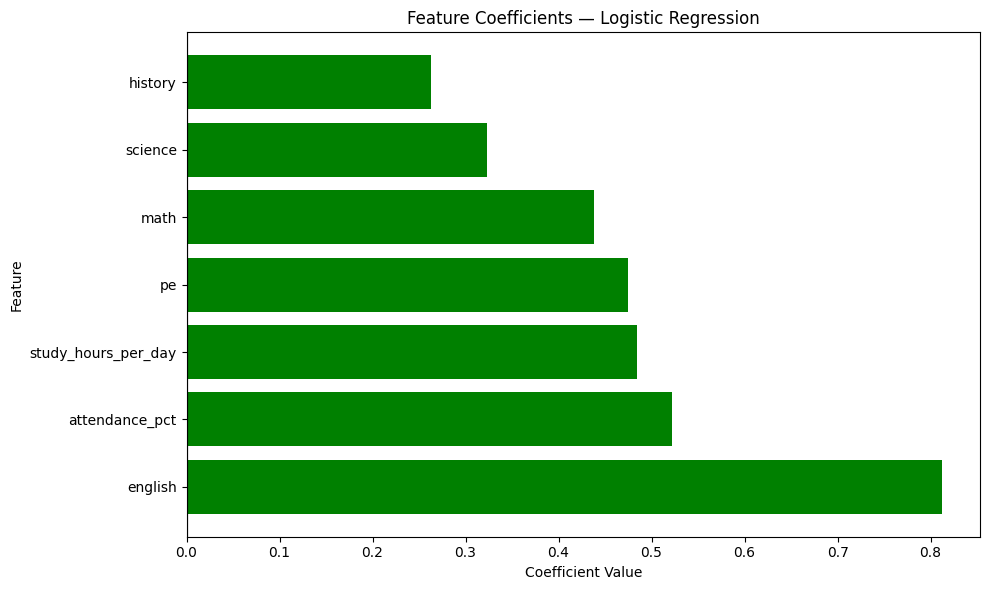


New Student Prediction : Pass
Probability — Fail: 0.09 | Pass: 0.91


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [5]:
# Task 4 — Machine Learning with scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Step 1 — Prepare Data
feature_cols = ['math', 'science', 'english', 'history', 'pe', 'attendance_pct', 'study_hours_per_day']
X = df[feature_cols]
y = df['passed']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Step 2 — Train Model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
train_accuracy = model.score(X_train_scaled, y_train)
print(f"Training Accuracy : {train_accuracy:.2f}")

# Step 3 — Evaluate Model
y_pred = model.predict(X_test_scaled)
test_accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy     : {test_accuracy:.2f}")

# Print each test student with actual vs predicted
print("\nPer Student Predictions: ")
test_names = df.loc[X_test.index, 'name']
for name, actual, predicted in zip(test_names, y_test, y_pred):
    result = "\U00002705 Correct" if actual == predicted else "\U0000274C Wrong"
    print(f"{name:<10} | Actual: {actual} | Predicted: {predicted} | {result}")

# Step 4 — Feature Importance sorted by absolute value
coefficients = model.coef_[0]
feature_importance = sorted(zip(feature_cols, coefficients), key=lambda x: abs(x[1]), reverse=True)

print("\nFeature Coefficients sorted by importance: ")
for feature, coef in feature_importance:
    print(f"{feature:<25} : {coef:.4f}")

# Horizontal bar chart of feature coefficients
colors = ['green' if c > 0 else 'red' for _, c in feature_importance]
features = [f for f, _ in feature_importance]
coefs    = [c for _, c in feature_importance]

plt.figure(figsize=(10, 6))
plt.barh(features, coefs, color=colors)
plt.title("Feature Coefficients — Logistic Regression")
plt.xlabel("Coefficient Value")
plt.ylabel("Feature")
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.savefig("plot8_feature_importance.png")
plt.show()

# Step 5 — Predict for a New Student
new_student = [[75, 70, 68, 65, 80, 82, 3.2]]
new_scaled  = scaler.transform(new_student)
prediction  = model.predict(new_scaled)
probability = model.predict_proba(new_scaled)

result = "Pass" if prediction[0] == 1 else "Fail"
print(f"\nNew Student Prediction : {result}")
print(f"Probability — Fail: {probability[0][0]:.2f} | Pass: {probability[0][1]:.2f}")